# 05 — Walk-forward GBM results (Case B)

Final evaluation and reporting for the expanding-window global `HistGradientBoostingRegressor`:

- train on `date < t`, score `date == t` for each Tuesday `t ≥ 2025-01-07`
- features via `LaneWeekFeatureBuilder` (lagged RPM + `availability_lag_1`; no same-week availability / rate bands)
- **residual target:** learn `delta = rpm − rpm_lag_1`, then `pred = rpm_lag_1 + deltâ`
- baseline = `rpm_lag_1`
- **hyperparameters:** loads θ* from `models/nested_hpo/best_params.json` (run notebook **04** first)

Modeling panel includes Case-B as-of US diesel (`diesel_us`, `diesel_distance`).

Prefer the reproducible script for full runs:

```bash
python scripts/train_walkforward_gbm.py
```

This notebook loads saved metrics (or re-runs with θ*), prints the **dual-regime headline** (overall MAE vs lag-1 **and** cold-start 0–4 lift), plots weekly MAE / actual vs predicted, lane×time error heatmaps, and an optional diesel ablation comparison.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from freight_rates.evaluation import dual_regime_headline, format_dual_regime_report
from freight_rates.ingestion import load_raw_snapshot
from freight_rates.preprocessing import build_modeling_panel
from freight_rates.splits import filter_model_window
from freight_rates.walkforward import (
    default_gbm,
    load_hpo_best_params,
    run_walkforward_gbm,
    save_walkforward_outputs,
)

ROOT = Path("..").resolve()
OUT = ROOT / "models" / "walkforward_gbm"
HPO_PARAMS_PATH = ROOT / "models" / "nested_hpo" / "best_params.json"
ABLATION_DIR = ROOT / "models" / "diesel_ablation"
PRED_PATH = OUT / "walkforward_gbm_predictions.parquet"
WEEK_PATH = OUT / "walkforward_gbm_metrics_by_week.csv"
HIST_PATH = OUT / "walkforward_gbm_metrics_by_history.csv"
OVERALL_PATH = OUT / "walkforward_gbm_metrics_overall.csv"
DUAL_PATH = OUT / "walkforward_gbm_metrics_dual_regime.csv"
ABLATION_PATH = ABLATION_DIR / "diesel_ablation_comparison.csv"


In [ ]:
need_rerun = True
if PRED_PATH.exists() and WEEK_PATH.exists() and HIST_PATH.exists():
    preds = pd.read_parquet(PRED_PATH)
    # Re-run if artifacts predate residual targeting (missing delta_hat).
    need_rerun = "delta_hat" not in preds.columns

if not need_rerun:
    by_week = pd.read_csv(WEEK_PATH, parse_dates=["date"])
    by_history = pd.read_csv(HIST_PATH)
    overall = pd.read_csv(OVERALL_PATH)
    print("Loaded saved walk-forward outputs from", OUT)
else:
    if HPO_PARAMS_PATH.exists():
        hpo_params = load_hpo_best_params(HPO_PARAMS_PATH)
        model = default_gbm(**hpo_params)
        print("Using θ* from", HPO_PARAMS_PATH, ":", hpo_params)
    else:
        model = None
        print(
            f"No {HPO_PARAMS_PATH}; falling back to default_gbm(). "
            "Run notebook 04 first for tuned hyperparameters."
        )
    print("Running walk-forward with residual target (may take a few minutes)...")
    raw_dir = ROOT / "data" / "raw"
    panel = filter_model_window(
        build_modeling_panel(load_raw_snapshot(raw_dir=raw_dir), raw_dir=raw_dir)
    )
    result = run_walkforward_gbm(
        panel,
        model=model,
        residual_target=True,
        diesel_features="level",
        verbose=True,
    )
    save_walkforward_outputs(result, OUT)
    preds, by_week, by_history, overall = (
        result.predictions,
        result.by_week,
        result.by_history,
        result.overall,
    )

headline = dual_regime_headline(overall, by_history, label="full")
headline.to_csv(DUAL_PATH, index=False)
print(format_dual_regime_report(headline))
print()
print(
    "Interpretation: beat lag-1 overall is optional; cold-start (0-4) lift is the "
    "primary success criterion for the global residual GBM."
)
print()
display(overall)
display(by_history)
display(headline)


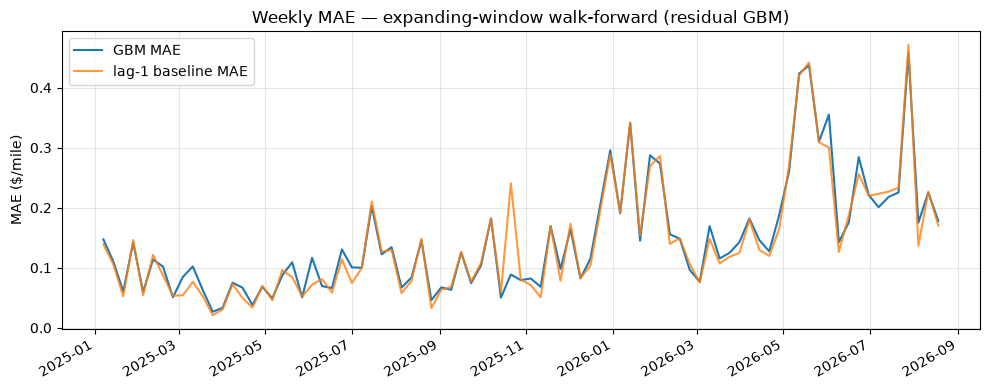

scored rows: 5,689


In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_week["date"], by_week["mae"], label="GBM MAE")
if "mae_baseline" in by_week.columns:
    ax.plot(by_week["date"], by_week["mae_baseline"], label="lag-1 baseline MAE", alpha=0.8)
ax.set_title("Weekly MAE — expanding-window walk-forward (residual GBM)")
ax.set_ylabel("MAE ($/mile)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"scored rows: {len(preds):,}")

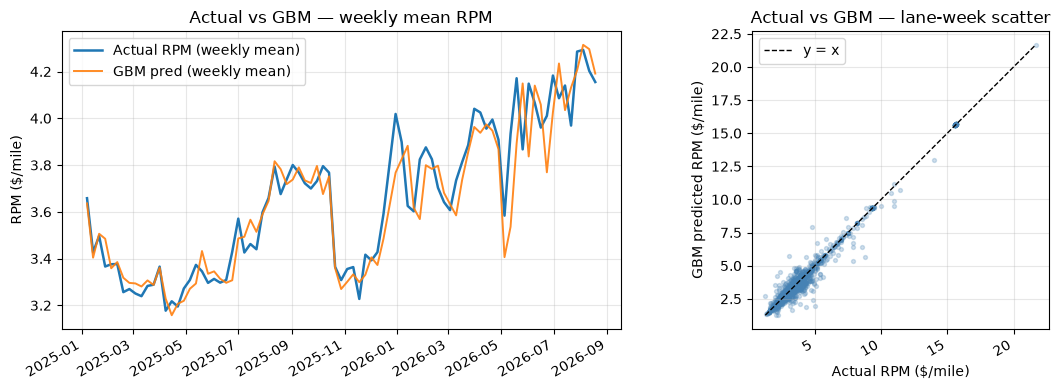

,date,rpm_true,rpm_gbm,rpm_lag1,n
0,2025-01-07,3.658201,3.635949,3.667572,89
1,2025-01-14,3.426901,3.403909,3.509720,89
2,2025-01-21,3.496844,3.506112,3.507820,79
3,2025-01-28,3.366109,3.484754,3.496844,79
4,2025-02-04,3.375722,3.358566,3.366109,79


In [4]:
# Actual vs GBM predicted RPM (weekly mean across lanes), plus scatter.
weekly_levels = (
    preds.groupby("date", as_index=False)
    .agg(
        rpm_true=("y_true", "mean"),
        rpm_gbm=("y_pred", "mean"),
        rpm_lag1=("y_pred_baseline", "mean"),
        n=("y_true", "size"),
    )
    .sort_values("date")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(weekly_levels["date"], weekly_levels["rpm_true"], label="Actual RPM (weekly mean)", lw=1.8)
axes[0].plot(weekly_levels["date"], weekly_levels["rpm_gbm"], label="GBM pred (weekly mean)", lw=1.4, alpha=0.9)
axes[0].set_title("Actual vs GBM — weekly mean RPM")
axes[0].set_ylabel("RPM ($/mile)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
fig.autofmt_xdate()

# Subsample for readability if many points
scatter = preds.sample(n=min(2500, len(preds)), random_state=42)
axes[1].scatter(scatter["y_true"], scatter["y_pred"], s=8, alpha=0.25, color="steelblue")
lims = [
    min(scatter["y_true"].min(), scatter["y_pred"].min()),
    max(scatter["y_true"].max(), scatter["y_pred"].max()),
]
axes[1].plot(lims, lims, color="black", lw=1, ls="--", label="y = x")
axes[1].set_xlabel("Actual RPM ($/mile)")
axes[1].set_ylabel("GBM predicted RPM ($/mile)")
axes[1].set_title("Actual vs GBM — lane-week scatter")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

weekly_levels.head()


## Diesel ablation — dual-regime comparison

Compare residual GBM with diesel modes ``none`` / ``level`` / ``full`` on the same panel.

```bash
python scripts/ablate_diesel_walkforward.py
```

Loads ``models/diesel_ablation/diesel_ablation_comparison.csv`` when present.


In [ ]:
if ABLATION_PATH.exists():
    ablation = pd.read_csv(ABLATION_PATH)
    display(ablation)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    x = range(len(ablation))
    labels = ablation["label"].tolist()

    axes[0].bar(x, ablation["mae"], color="steelblue", alpha=0.85, label="GBM MAE")
    if "mae_baseline" in ablation.columns:
        axes[0].axhline(
            ablation["mae_baseline"].iloc[0],
            color="gray",
            ls="--",
            lw=1.2,
            label="lag-1 MAE",
        )
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(labels)
    axes[0].set_ylabel("MAE ($/mile)")
    axes[0].set_title("Overall MAE by diesel mode")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, axis="y", alpha=0.3)

    axes[1].bar(x, ablation["cold_mae_lift"], color="darkgreen", alpha=0.85)
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel("MAE lift vs lag-1")
    axes[1].set_title("Cold-start (0–4) lift by diesel mode")
    axes[1].grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    if "delta_mae_vs_none" in ablation.columns:
        full = ablation.loc[ablation["label"] == "full"]
        if not full.empty:
            d = float(full["delta_mae_vs_none"].iloc[0])
            print(f"ΔMAE (full − none) = {d:+.4f}")
            if abs(d) < 0.002:
                print("→ |Δ| < 0.002: diesel is optional for overall MAE.")
else:
    print(
        f"No ablation file at {ABLATION_PATH}. "
        "Run: python scripts/ablate_diesel_walkforward.py"
    )


## Error heatmaps — which lanes / months hurt most

Absolute error `|y_true − y_pred|` by **lane × month** (lanes with ≥10 scored weeks) and **lane × week** for the worst 30. Rows sorted by overall lane MAE so high-error corridors sit at the top; empty cells are weeks with no observation for that lane.


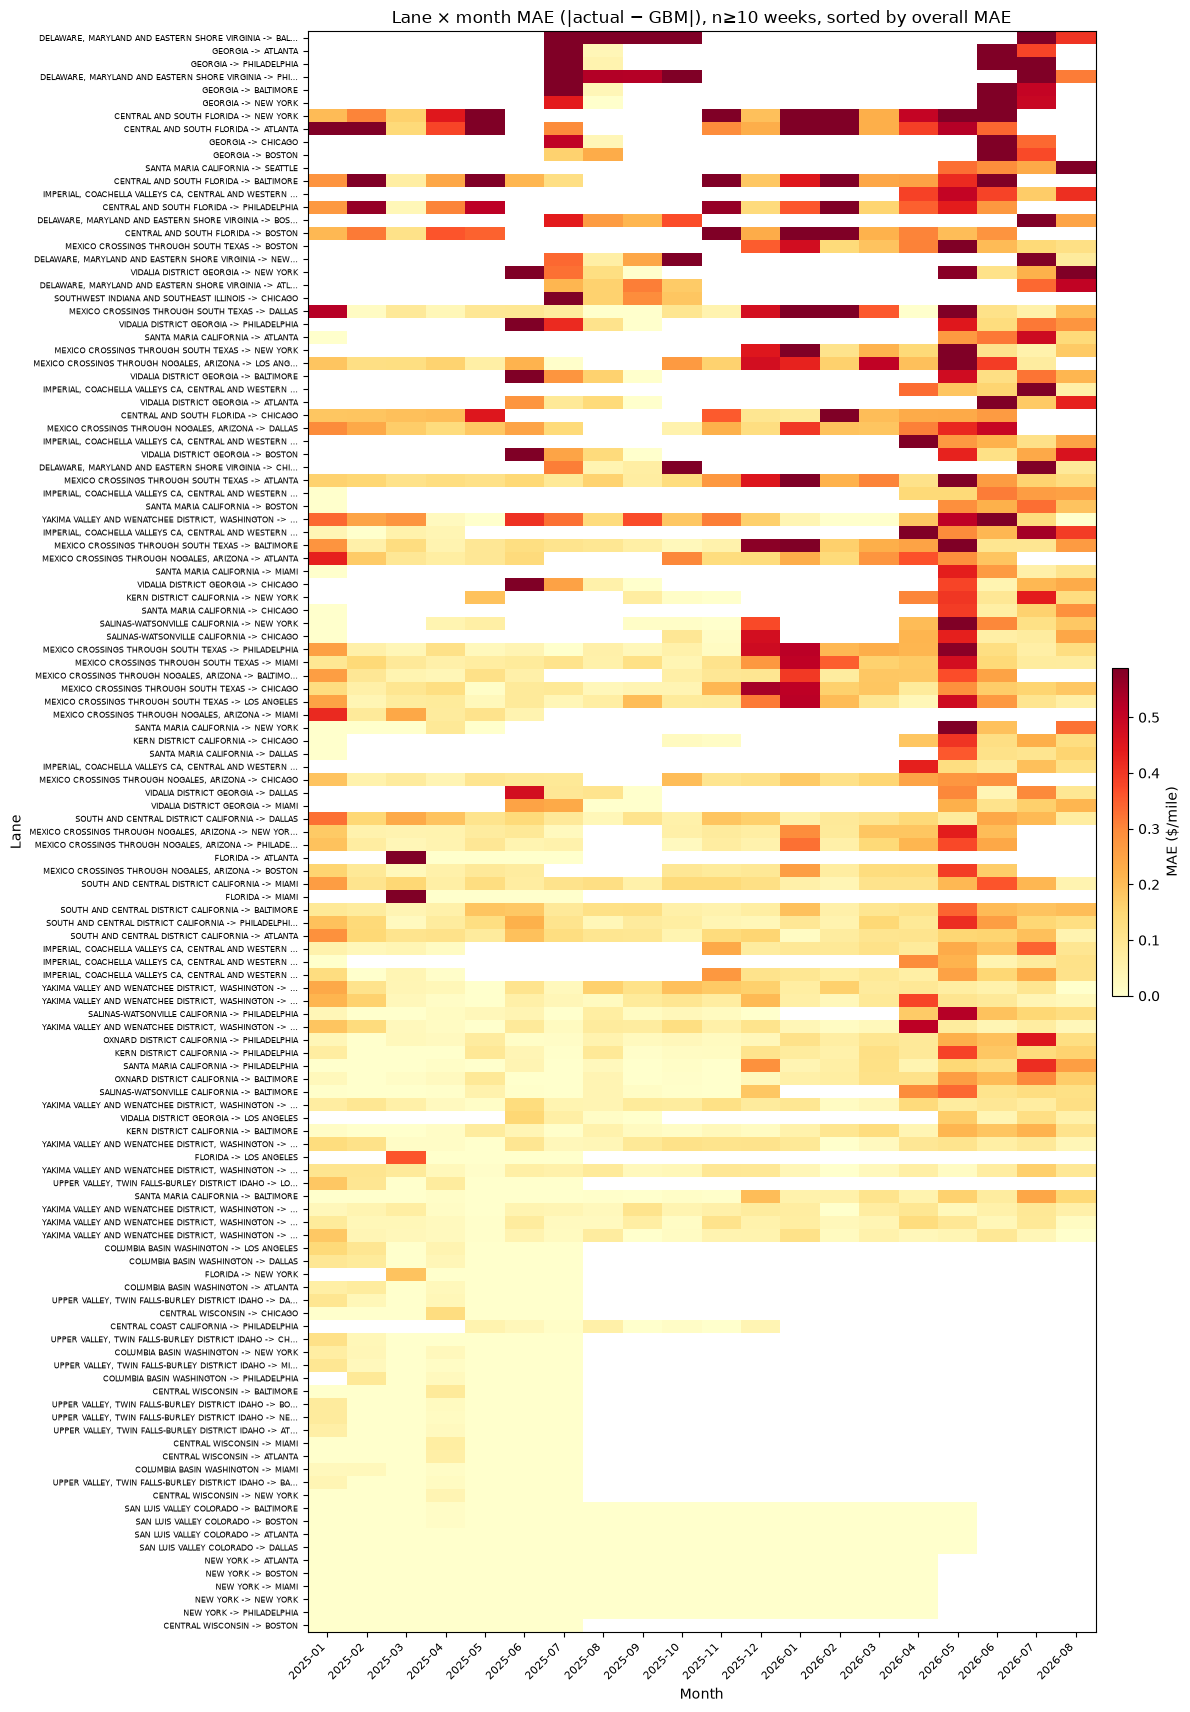

Worst lanes by overall MAE (n≥10):


,lane_id,mae,n
0,"DELAWARE, MARYLAND AND EASTERN SHORE VIRGINIA ...",1.042977,16
1,GEORGIA -> ATLANTA,0.771173,10
2,GEORGIA -> PHILADELPHIA,0.756680,10
3,"DELAWARE, MARYLAND AND EASTERN SHORE VIRGINIA ...",0.756189,16
4,GEORGIA -> BALTIMORE,0.699431,10
5,GEORGIA -> NEW YORK,0.636313,10
6,CENTRAL AND SOUTH FLORIDA -> NEW YORK,0.512344,50
7,CENTRAL AND SOUTH FLORIDA -> ATLANTA,0.509379,51
8,GEORGIA -> CHICAGO,0.503674,10
9,GEORGIA -> BOSTON,0.487645,10


Worst lanes including sparse (any n):


,lane_id,mae,n
0,NORTH CAROLINA -> BALTIMORE,1.231102,4
1,CENTRAL AND NORTH FLORIDA -> BALTIMORE,1.159150,1
2,"DELAWARE, MARYLAND AND EASTERN SHORE VIRGINIA ...",1.042977,16
3,NORTH CAROLINA -> NEW YORK,0.917099,4
4,GEORGIA -> ATLANTA,0.771173,10
5,GEORGIA -> PHILADELPHIA,0.756680,10
6,"DELAWARE, MARYLAND AND EASTERN SHORE VIRGINIA ...",0.756189,16
7,GEORGIA -> BALTIMORE,0.699431,10
8,NORTH CAROLINA -> PHILADELPHIA,0.671380,4
9,NORTH CAROLINA -> BOSTON,0.643607,4


In [5]:
import numpy as np

err = preds.copy()
err["date"] = pd.to_datetime(err["date"])
err["abs_err"] = (err["y_true"] - err["y_pred"]).abs()
err["month"] = err["date"].dt.to_period("M").astype(str)

lane_mae = (
    err.groupby("lane_id", as_index=False)
    .agg(mae=("abs_err", "mean"), n=("abs_err", "size"))
    .sort_values(["mae", "n"], ascending=[False, False])
    .reset_index(drop=True)
)

# Prefer lanes with enough scored weeks so outliers with 1–4 obs do not dominate.
MIN_WEEKS = 10
lane_mae_stable = (
    lane_mae.loc[lane_mae["n"] >= MIN_WEEKS]
    .sort_values(["mae", "n"], ascending=[False, False])
    .reset_index(drop=True)
)

# Monthly MAE: lanes (Y) × calendar month (X)
month_pivot = (
    err.groupby(["lane_id", "month"])["abs_err"]
    .mean()
    .unstack("month")
    .reindex(index=lane_mae_stable["lane_id"], columns=sorted(err["month"].unique()))
)

short_lane = [
    (lid[:52] + "…" if len(lid) > 52 else lid) for lid in month_pivot.index
]
vmax = float(np.nanpercentile(month_pivot.to_numpy(dtype=float), 95))

fig, ax = plt.subplots(figsize=(12, max(8, 0.14 * len(month_pivot))))
im = ax.imshow(
    month_pivot.to_numpy(dtype=float),
    aspect="auto",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=vmax,
    interpolation="nearest",
)
ax.set_xticks(range(len(month_pivot.columns)))
ax.set_xticklabels(month_pivot.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(month_pivot.index)))
ax.set_yticklabels(short_lane, fontsize=6)
ax.set_title(
    f"Lane × month MAE (|actual − GBM|), n≥{MIN_WEEKS} weeks, sorted by overall MAE"
)
ax.set_xlabel("Month")
ax.set_ylabel("Lane")
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("MAE ($/mile)")
plt.tight_layout()
plt.show()

print(f"Worst lanes by overall MAE (n≥{MIN_WEEKS}):")
display(lane_mae_stable.head(15))
print("Worst lanes including sparse (any n):")
display(lane_mae.head(10))


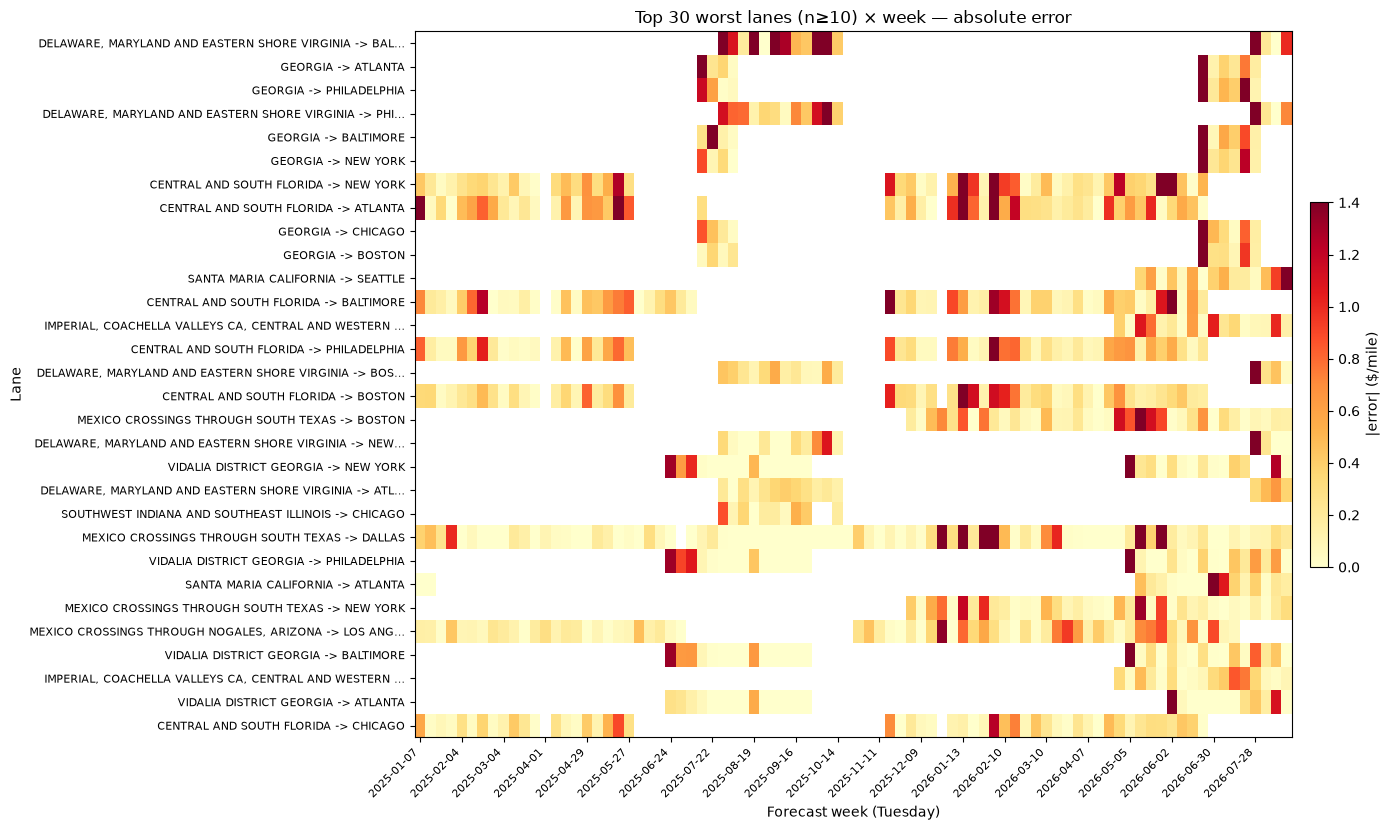

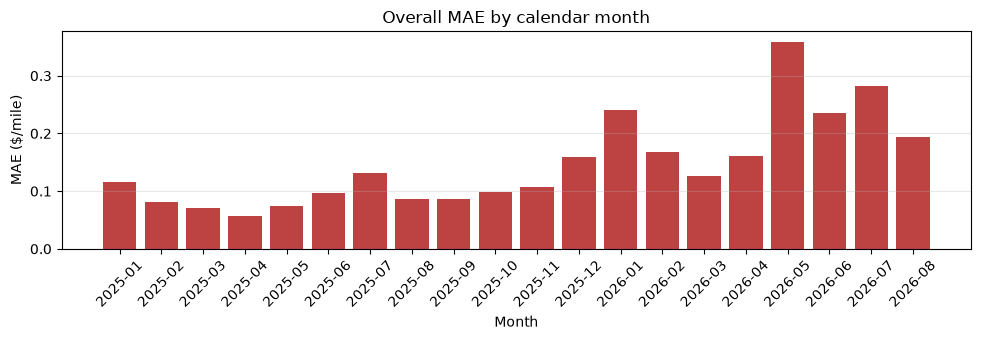

,month,mae,n
16,2026-05,0.359009,293
18,2026-07,0.281621,276
12,2026-01,0.241162,220
17,2026-06,0.236185,376
19,2026-08,0.193237,216
13,2026-02,0.168573,220
15,2026-04,0.161307,247
11,2025-12,0.158997,224


In [6]:
# Weekly absolute error for the worst TOP_N stable lanes (finer time grain).
TOP_N = 30
worst_lanes = lane_mae_stable.head(TOP_N)["lane_id"].tolist()
week_labels = sorted(err["date"].unique())
week_pivot = (
    err.loc[err["lane_id"].isin(worst_lanes)]
    .groupby(["lane_id", "date"])["abs_err"]
    .mean()
    .unstack("date")
    .reindex(index=worst_lanes, columns=week_labels)
)

short_worst = [
    (lid[:52] + "…" if len(lid) > 52 else lid) for lid in week_pivot.index
]
vmax_w = float(np.nanpercentile(week_pivot.to_numpy(dtype=float), 95))

fig, ax = plt.subplots(figsize=(14, max(6, 0.28 * TOP_N)))
im = ax.imshow(
    week_pivot.to_numpy(dtype=float),
    aspect="auto",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=vmax_w,
    interpolation="nearest",
)
tick_idx = list(range(0, len(week_labels), 4))
ax.set_xticks(tick_idx)
ax.set_xticklabels(
    [pd.Timestamp(week_labels[i]).strftime("%Y-%m-%d") for i in tick_idx],
    rotation=45,
    ha="right",
    fontsize=8,
)
ax.set_yticks(range(len(week_pivot.index)))
ax.set_yticklabels(short_worst, fontsize=8)
ax.set_title(f"Top {TOP_N} worst lanes (n≥{MIN_WEEKS}) × week — absolute error")
ax.set_xlabel("Forecast week (Tuesday)")
ax.set_ylabel("Lane")
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("|error| ($/mile)")
plt.tight_layout()
plt.show()

# Month-level MAE across all lanes (when the model struggles globally)
by_month = (
    err.groupby("month", as_index=False)
    .agg(mae=("abs_err", "mean"), n=("abs_err", "size"))
    .sort_values("month")
)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(by_month["month"], by_month["mae"], color="firebrick", alpha=0.85)
ax.set_title("Overall MAE by calendar month")
ax.set_ylabel("MAE ($/mile)")
ax.set_xlabel("Month")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
display(by_month.sort_values("mae", ascending=False).head(8))
